# Aula 2 - Como as Redes Neurais Aprendem? - Conceitos Preliminares

## Derivada

### Derivada Unidimensional

Revisaremos o conceito de derivada por meio de uma função exemplo,
$$
    f(x) = 3x^2 - 4x + 5.
$$
Em `Python`, podemos expressá-la como

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

Note que `f(3.0)` nos retornará o valor correto
$$
    f(3) = 3 \cdot 3^2 - 4 \cdot 3 + 5 = 27 - 12 + 5 = 20.
$$

In [3]:
f(3.0)

20.0

Claro que, conforme um curso de cálculo ensina, poderíamos calcular a derivada de $f$ em qualquer ponto $x$ simbolicamente. Neste caso, isso seria
$$
\begin{aligned}
    \frac{df}{dx}
    &= \frac{d\left(3x^2 - 4x + 5\right)}{dx} \\
    &= \frac{d(3x^2)}{dx} - \frac{d(4x)}{dx} + \frac{d(5)}{dx} \\
    &= 2\cdot 3x - 4 + 0 \\
    &= 6x - 4.
\end{aligned}
$$
Para o ponto $x=3$ já citado, por exemplo, sua derivada seria
$$
    \frac{df}{dx}(3) = 6\cdot3 -4 = 14.
$$
Entretanto, as 'funções de perda' de redes neurais, se fossem ser escritas, teriam milhões de termos, não só três, como esta $f$. Logo, em nosso contexto, interessa-nos menos saber como calcular derivadas de funções particulares e sim em entender bem a **definição** de derivada; que tipo de informação ela nos dá sobre uma função.

Já adianto que, por definição, a derivada de $f$ no ponto $x=3$ é dada pela expressão
$$
\frac{df}{dx}(3) = \lim_{h\to0} \frac{f(3+h) - f(3)}{h}.
$$
Entretanto, construamos essa expressão com calma, por partes, para ficar claro porque ela representa a **taxa de variação** de $f$ na vizinhança de $x=3$.

Para começar, façamos uso de um recurso visual: o gráfico de $f$. Conseguimos construir este gráfico com `Python`. Para começar, importemos a biblioteca `numpy`, que mune o `Python` de uma série de ferramentas numéricas; daí o nome `num`/`py`.

In [4]:
import numpy as np

Note que apelidamos `numpy` de `np` na importação, por brevidade.

Agora, escolhamos um conjunto de valores de $x$ sobre os quais computar $f(x)$. Podemos, por exemplo, escolher os valores de $-5$ a $5$, em incrementos de $0.1$. É possível instanciar estes valores em uma única linha de código utilizando o `numpy`.

In [5]:
xs = np.arange(-5, 5, 0.1)

# Abaixo, código para visualizarmos `xs`
# Não é o enfoque da aula
np.set_printoptions(suppress=True)
print(xs)

[-5.  -4.9 -4.8 -4.7 -4.6 -4.5 -4.4 -4.3 -4.2 -4.1 -4.  -3.9 -3.8 -3.7
 -3.6 -3.5 -3.4 -3.3 -3.2 -3.1 -3.  -2.9 -2.8 -2.7 -2.6 -2.5 -2.4 -2.3
 -2.2 -2.1 -2.  -1.9 -1.8 -1.7 -1.6 -1.5 -1.4 -1.3 -1.2 -1.1 -1.  -0.9
 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1 -0.   0.1  0.2  0.3  0.4  0.5
  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3  1.4  1.5  1.6  1.7  1.8  1.9
  2.   2.1  2.2  2.3  2.4  2.5  2.6  2.7  2.8  2.9  3.   3.1  3.2  3.3
  3.4  3.5  3.6  3.7  3.8  3.9  4.   4.1  4.2  4.3  4.4  4.5  4.6  4.7
  4.8  4.9]


O `Python` possui uma grande flexibilidade em suas funções. Se passarmos `xs`, uma lista de valores, à nossa função `f`, ela já sabe que deveria calcular o valor de `f` sobre cada elemento de `xs` individualmente.

In [6]:
ys = f(xs)

# Visualização de `ys`
print(ys)

[100.    96.63  93.32  90.07  86.88  83.75  80.68  77.67  74.72  71.83
  69.    66.23  63.52  60.87  58.28  55.75  53.28  50.87  48.52  46.23
  44.    41.83  39.72  37.67  35.68  33.75  31.88  30.07  28.32  26.63
  25.    23.43  21.92  20.47  19.08  17.75  16.48  15.27  14.12  13.03
  12.    11.03  10.12   9.27   8.48   7.75   7.08   6.47   5.92   5.43
   5.     4.63   4.32   4.07   3.88   3.75   3.68   3.67   3.72   3.83
   4.     4.23   4.52   4.87   5.28   5.75   6.28   6.87   7.52   8.23
   9.     9.83  10.72  11.67  12.68  13.75  14.88  16.07  17.32  18.63
  20.    21.43  22.92  24.47  26.08  27.75  29.48  31.27  33.12  35.03
  37.    39.03  41.12  43.27  45.48  47.75  50.08  52.47  54.92  57.43]


Com `xs` e `ys` em mãos, conseguimos agora desenhar o gráfico de `f`, basta importarmos mais uma biblioteca, `matplotlib`. Na realidade, basta apenas um módulo seu específico, `pyplot`.

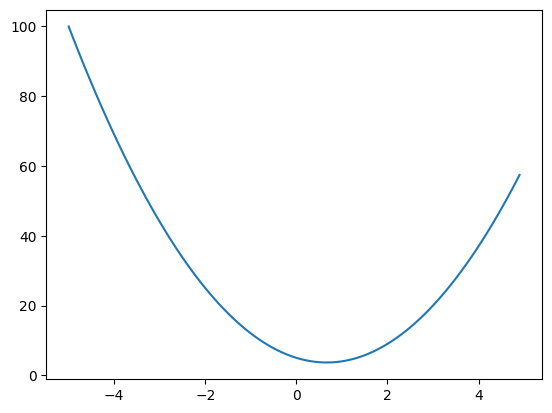

In [7]:
import matplotlib.pyplot as plt
plt.plot(xs, ys)

Esse gráfico nos dará um bom complemento visual para entendermos as operações matemáticas que faremos agora.

Para começar, se dermos um pequeno incremento $h$ (digamos de $0.01$) a $3$, o que acontece com o valor de $f(3+h)$? Aumenta? Diminui? Muito? Só um pouco? Tente descobrir olhando o gráfico e, depois, veja a resposta abaixo.

In [8]:
h = 0.01
f(3+h)

20.140299999999996

Vemos que o valor de $f(3+h)$ é ligeiramente maior do que o de $f(3)$, portanto, este pequeno incremento na entrada da função levou também a um incremento em sua saída. Isso fica mais fácil de identificar se ao invés de só calcularmos $f(3+h)$, calcularmos sua diferença em relação ao valor base $f(3)$,
$$
f(3+h) - f(3).
$$

In [9]:
f(3+h) - f(3)

0.14029999999999632

Note que para um ponto $x$ qualquer, não necessariamente $x=3$, chegamos no seguinte esquema para a vizinhança do ponto $x$:
* Se $f(x+h) - f(x) > 0$, então um incremento na entrada leva a um incremento na saída da função.
* Se $f(x+h) - f(x) < 0$, inversamente, um incremento na entrada leva a um decremento na saída da função.
* Se $f(x+h) - f(x) = 0$, por fim, um incremento na entrada não altera a saída da função.

Mas, e se o incremento fosse ainda menor que $0.01$, digamos, $h=0.0005$? Que variação na saída produz essa pequeníssima variação na entrada?

In [10]:
h = 0.0005
f(3+h) - f(3)

0.007000750000003109

Ainda temos que $f(3+h)-f(3) > 0$, indicando crescimento da função. Entretanto, vemos que agora o incremento à saída de $f$ é muito mais próxima de $0$.

Se olharmos o gráfico da função novamente, esse comportamento é de se esperar. Nossa nova perturbação na entrada é muito menor do que a original, então é natural que a diferença na saída também seja muito menor.

Isso, contudo, é um tanto problemático, pois queremos saber como a saída de $f$ varia ao deslocarmos de $3$ a seus valores vizinhos, incluindo aqueles arbitrariamente próximos de $3$. Todavia, existe solução: ao invés de calcularmos a variação absoluta $f(3+h) - f(3)$, podemos calcular uma variação relativa ao tamanho do incremento:
$$
\frac{f(3+h)-f(3)}{h}.
$$

In [11]:
(f(3+h) - f(3)) / h

14.001500000006217

Agora, obtemos um valor próximo de $14$. A grande melhoria é que, além do sinal deste número nos dar uma informação qualitativa da variação de $f$ (se cresce ou decresce), o valor em si agora carrega informação também. Dá uma medida quantitativa de quão brusca ou amena é tal variação.

Um incremento $h$ na entrada leva a um incremento de aproximadamente $14\,h$ no valor da saída. Um crescimento brusco! Simbolicamente:
$$
\frac{f(3+h)}{h} \approx 14 \implies f(3+h) \approx f(3) + 14\,h.
$$

Daqui para a expressão definitiva da derivada, falta apenas aplicarmos a operação de limite $\lim_{h\to0}$, ou seja, considerar um incremento $h$ arbitrariamente pequeno (mas nunca nulo!). Isso nos levará ao valor redondo $\frac{df}{dx}(3)=14$, concordando com nossa derivação simbólica.

Note, contudo, que, computacionalmente, não é possível implementar a operação $\lim_{h\to0}$, já que os números no computador tem precisão finita.

De toda forma, espero que agora, quando verem expressões do tipo $\frac{df}{dx}(0) = -4$ ou $\frac{df}{dx}(0.75) = 0.5$, seja possível entender como a função está variando nas redondezas do valor base.

### Regra da Cadeia

Nas redes neurais, veremos muitas funções **compostas**, cujas derivadas desejaremos determinar. Por exemplo, considere que as grandezas $x$, $y$ e $z$ se relacionam da seguinte forma
$$
    y = f_1(x) = 2x + 3,
    \qquad\qquad
    z = f_2(y) = y^2.
$$
Em código:

In [12]:
def f1(x):
    return 2*x + 3

def f2(y):
    return y**2


In [13]:
x = 1.0
y = f1(x)
z = f2(y)

print(f"x = {x}, y = {y} e z = {z}")

x = 1.0, y = 5.0 e z = 25.0


Então, a grandeza $z$, de forma explícita, se relaciona à $x$ na forma
$$
\begin{aligned}
    z
    &= f_2(y) \\
    &= f_2(f_1(x)) \\
    &= (f_1(x))^2 \\
    &= \bigl(2x + 3\bigr)^2 \\
    &= 4x^2 + 12x + 9.
\end{aligned}
$$
Em código essa relação explícita, digamos $f_3$, pode ser expressa como:

In [14]:
def f3(x):
    return 4*x**2 + 12*x +9

In [15]:
f2(f1(x)) == f3(x)

True

Entretanto, para determinarmos como $z$ varia com $x$, isto é, $\frac{dz}{dx}$, não precisamos escrever $z$ explicitamente em termos de $x$. Ao invés, podemos poupar trabalho usando a regra da cadeia:
$$
    \frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx}.
$$
Para adquirirmos uma intuição sobre essa regra, vejamos o que diz o matemático americano George F. Simmons: *Se um carro anda duas vezes mais rápido do que uma bicicleta e a bicicleta, por sua vez, anda quatro vezes mais rápido do que um pedestre, então, o carro anda $2 \times 4 = 8$ vezes mais rápido do que o pedestre.*

Neste exemplo de Simmons, $z$, $y$ e $x$ denotam a posição do carro, bicicleta e pedestre, respectivamente. Se o carro anda duas vezes mais rápido que a bicicleta, então, a taxa de variação de suas posições relativas é $\frac{dz}{dy} = 2$. Analogamente, se a bicicleta anda quatro vezes mais rápido do que o pedestre, $\frac{dy}{dx} = 4$. Logo,
$$
    \frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx} = 2 \cdot 4 = 8.
$$
Retornando a nosso exemplo original, temos que
$$
    \frac{dz}{dy} = 2y,
    \qquad\qquad
    \frac{dy}{dx} = 2
$$
Logo,
$$
\begin{aligned}
    \frac{dz}{dx}
    &= 2y \cdot 2 \\
    &= 4y \\
    &= 4(2x+3) \\
    &= 8x + 3.
\end{aligned}
$$
Verifique que $\frac{d(4x^2 + 12x + 9)}{dx}$, a derivada da expressão explícita de $z$ em termos de $x$, leva ao mesmo resultado.

In [16]:
h = 0.001

dydx = (f1(x+h) - f1(x))/h
dzdy = (f2(y+h) - f2(y))/h


print("dy/dx =",dydx)
print("dz/dy =",dzdy)

dy/dx = 1.9999999999997797
dz/dy = 10.001000000002591


In [17]:
dzdx = (f3(x+h) - f3(x))/h

print("dz/dx(x0) =",dzdx)

dz/dx(x0) = 20.00399999999658


### Derivada Multidimensional

Redes neurais são máquinas de muitos parâmetros ajustáveis, não apenas um, então, precisa estar fresco em nossas mentes como derivar função de várias variáveis.

Novamente, façamos isso por meio de uma função exemplo e com um enfoque computacional. Consideremos a função
$$
    g(x,y,z) = xy + z.
$$
Em `Python`,

In [18]:
def g(x,y,z):
    return x*y + z

Qual a derivada de $g$, por exemplo, no ponto $(x,y,z) = (2,-3,10)$?

In [19]:
x = 2.0
y = -3.0
z = 10.0

A pergunta é capciosa, pois agora uma derivada não nos basta. Precisamos de três, para avaliar o efeito de cada uma das três entradas sobre a saída de forma independente:
$$
    \frac{\partial g}{\partial x}(2,-3,10), \qquad
    \frac{\partial g}{\partial y}(2,-3,10) \quad\text{e}\quad
    \frac{\partial g}{\partial z}(2,-3,10),
$$
onde $\partial$ é usado no lugar de $d$ para enfatizar que $g$ é função de múltiplas variáveis.

Em $\frac{\partial g}{\partial x}(2,-3,10)$, por exemplo, consideramos um incremento
$$
    (2,-3,10) + (h, 0, 0) = (2+h,-3,10).
$$
A variável $x$ é perturbada ao passo que as outras são mantidas constantes e, por isso, leva o nome de **derivada parcial**. As outras duas derivadas parciais possuem comportamento análogo.

Novamente, objetivamos uma boa intuição do que essas três derivadas parciais estão nos informando mais do que recordar precisamente como determiná-las simbolicamente.

Por isso mesmo, dessa vez nem faremos a dedução simbólica, partiremos diretamente a uma estimação numérica de seus valores. Antes porém, tentem prever mentalmente se cada uma das derivadas será positiva ou negativa.

In [20]:
h = 0.0001

dgdx = (g(x+h,y,z) - g(x,y,z)) / h

dgdy = (g(x,y+h,z) - g(x,y,z)) / h

dgdz = (g(x,y,z+h) - g(x,y,z)) / h


print("dg/dx(2,-3,10) ≈ ",dgdx)
print("dg/dy(2,-3,10) ≈ ",dgdy)
print("dg/dz(2,-3,10) ≈ ",dgdz)

dg/dx(2,-3,10) ≈  -3.000000000010772
dg/dy(2,-3,10) ≈  2.0000000000042206
dg/dz(2,-3,10) ≈  0.9999999999976694


Baseado no código acima, podemos concluir que, no ponto $(2,-3,10)$,
* um acréscimo no valor de $x$ leva a um decréscimo no valor de $g$ três vezes maior (em módulo);
* um acréscimo no valor de $y$ leva a um acréscimo no valor de $g$ duas vezes maior;
* um acréscimo no valor de $z$ leva a um acréscimo no valor de $g$ do mesmo tamanho.

Por fim, vale a pena comentar que podemos juntar, por fins de organização, as três derivadas em um vetor de $\mathbb{R}^3$:
$$
    \begin{bmatrix}
        \frac{\partial g}{\partial x} \\
        \\
        \frac{\partial g}{\partial y} \\
        \\
        \frac{\partial g}{\partial z}
    \end{bmatrix}
$$
Este vetor leva o nome de **gradiente** de $g$ e é denotado por $\nabla g$.